# Symmetric vs. Asymmetric INT8 Quantization

### Import Required Libraries

In [111]:
import torch
import numpy as np
from IPython.display import Image

### Part A : Symmetric INT8 Quantization

In [14]:
def symmetric_quantize(tensor):
    x_max = tensor.abs().max().item()
    scale = x_max / 127
    scaled_and_shifted_tensor = tensor/scale
    quantized_tensor = torch.round(scaled_and_shifted_tensor).to(torch.int8)
    return quantized_tensor, scale, 0

### Part B : Asymmetric INT8 Quantization

In [48]:
def asymmetric_quantize(tensor):
    x_max, x_min = tensor.max().item(), tensor.min().item()
    if x_min == x_max:
        scale =  1.0
    else:
        scale = (x_max - x_min) / 255
    zero_point = int(round(-128 - x_min / scale))
    if zero_point < -128:
        zero_point = - 128
    elif zero_point > 127:
        zero_point = 127
    quantized_tensor = torch.round(tensor / scale + zero_point)
    quantized_tensor = torch.clamp(quantized_tensor, -128, 127).to(torch.int8)
    return quantized_tensor, scale, zero_point

### Part C : Dequantization

In [3]:
def dequantize(quantized_tensor, scale, zero_point):
    return scale * (quantized_tensor.float() - zero_point)

### Part D : Apply Both Methods and Compare

##### Input

In [6]:
weights = np.array([ 
    [-1.8, -0.9, 0.0, 0.7, 1.5], 
    [-2.4, -0.3, 0.2, 1.1, 2.0] 
], dtype=np.float32) 
activations = np.array([ 
    [0.0, 0.3, 0.8, 1.4, 2.1], 
    [0.1, 0.6, 1.0, 1.8, 3.2] 
], dtype=np.float32) 

In [7]:
weights = torch.tensor(weights)
activations = torch.tensor(activations)

##### Apply Symmetric Quantization on Weights

In [57]:
symm_quantized_weights, scale, zero_point = symmetric_quantize(weights)
symm_dequantized_weights =  dequantize(symm_quantized_weights, scale, zero_point)
abs_error = torch.abs(weights - symm_dequantized_weights)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (symm_dequantized_weights - weights).square().mean()
max_error = torch.max(abs_error)
sat_min = torch.sum(symm_quantized_weights == -127).item()
sat_max = torch.sum(symm_quantized_weights == 127).item()
sat_total = sat_min + sat_max

In [58]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)
print("Saturation (min): ", sat_min)
print("Saturation (max): ", sat_max)
print("Saturation (total): ", sat_total)

Scale:  0.01889763854620025
Zero point:  0
Mean Absolute Error:  tensor(0.0037)
Mean Squared Error:  tensor(2.1638e-05)
Max Error:  tensor(0.0079)
Saturation (min):  1
Saturation (max):  0
Saturation (total):  1




##### Apply Asymmetric Quantization on Weights

In [61]:
asymm_quantized_weights, scale, zero_point = asymmetric_quantize(weights)
asymm_dequantized_weights =  dequantize(asymm_quantized_weights, scale, zero_point)
abs_error = torch.abs(weights - asymm_dequantized_weights)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (asymm_dequantized_weights - weights).square().mean()
max_error = torch.max(abs_error)
sat_min = torch.sum(asymm_quantized_weights == -128).item()
sat_max = torch.sum(asymm_quantized_weights == 127).item()
sat_total = sat_min + sat_max

In [62]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)
print("Saturation (min): ", sat_min)
print("Saturation (max): ", sat_max)
print("Saturation (total): ", sat_total)

Scale:  0.017254902334774242
Zero point:  11
Mean Absolute Error:  tensor(0.0038)
Mean Squared Error:  tensor(2.1238e-05)
Max Error:  tensor(0.0075)
Saturation (min):  1
Saturation (max):  1
Saturation (total):  2


##### Apply Symmetric Quantization on Activations

In [63]:
symm_quantized_activations, scale, zero_point = symmetric_quantize(activations)
symm_dequantized_activations =  dequantize(symm_quantized_activations, scale, zero_point)
abs_error = torch.abs(activations - symm_dequantized_activations)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (symm_dequantized_activations - activations).square().mean()
max_error = torch.max(abs_error)
sat_min = torch.sum(symm_quantized_activations == -127).item()
sat_max = torch.sum(symm_quantized_activations == 127).item()
sat_total = sat_min + sat_max

In [64]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)
print("Saturation (min): ", sat_min)
print("Saturation (max): ", sat_max)
print("Saturation (total): ", sat_total)

Scale:  0.02519685076916312
Zero point:  0
Mean Absolute Error:  tensor(0.0053)
Mean Squared Error:  tensor(4.4826e-05)
Max Error:  tensor(0.0110)
Saturation (min):  0
Saturation (max):  1
Saturation (total):  1


##### Apply Asymmetric Quantization on Activations

In [65]:
asymm_quantized_activations, scale, zero_point = asymmetric_quantize(activations)
asymm_dequantized_activations =  dequantize(asymm_quantized_activations, scale, zero_point)
abs_error = torch.abs(activations - asymm_dequantized_activations)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (asymm_dequantized_activations - activations).square().mean()
max_error = torch.max(abs_error)
sat_min = torch.sum(asymm_quantized_activations == -128).item()
sat_max = torch.sum(asymm_quantized_activations == 127).item()
sat_total = sat_min + sat_max

In [66]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)
print("Saturation (min): ", sat_min)
print("Saturation (max): ", sat_max)
print("Saturation (total): ", sat_total)

Scale:  0.012549019794838101
Zero point:  -128
Mean Absolute Error:  tensor(0.0026)
Mean Squared Error:  tensor(1.1119e-05)
Max Error:  tensor(0.0055)
Saturation (min):  1
Saturation (max):  1
Saturation (total):  2


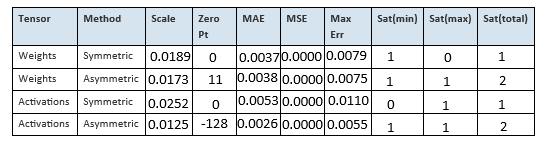

In [112]:
Image(filename="Documents/Observation.png")

### Part E : Compare Reconstructed Values

##### Tensor - Weights

In [70]:
print("Tensor - Weights")
print("Original   | Sym INT8   | Sym Deq    | Asym INT8  | Asym Deq")
print("-" * 65)
for i in range(weights.shape[0]):        
    for j in range(weights.shape[1]):  
        orig_val = weights[i, j].item()
        q_sym_val = symm_quantized_weights[i, j].item()
        deq_sym_val = symm_dequantized_weights[i, j].item()
        q_asym_val = asymm_quantized_weights[i, j].item()
        deq_asym_val = asymm_dequantized_weights[i, j].item()
        print(f"{orig_val:10.2f} | {q_sym_val:10d} | {deq_sym_val:10.4f} | {q_asym_val:10d} | {deq_asym_val:10.4f}")

Tensor - Weights
Original   | Sym INT8   | Sym Deq    | Asym INT8  | Asym Deq
-----------------------------------------------------------------
     -1.80 |        -95 |    -1.7953 |        -93 |    -1.7945
     -0.90 |        -48 |    -0.9071 |        -41 |    -0.8973
      0.00 |          0 |     0.0000 |         11 |     0.0000
      0.70 |         37 |     0.6992 |         52 |     0.7075
      1.50 |         79 |     1.4929 |         98 |     1.5012
     -2.40 |       -127 |    -2.4000 |       -128 |    -2.3984
     -0.30 |        -16 |    -0.3024 |         -6 |    -0.2933
      0.20 |         11 |     0.2079 |         23 |     0.2071
      1.10 |         58 |     1.0961 |         75 |     1.1043
      2.00 |        106 |     2.0031 |        127 |     2.0016


##### Tensor - Activations

In [71]:
print("Tensor - Activations")
print("Original   | Sym INT8   | Sym Deq    | Asym INT8  | Asym Deq")
print("-" * 65)
for i in range(activations.shape[0]):        
    for j in range(activations.shape[1]):  
        orig_val = activations[i, j].item()
        q_sym_val = symm_quantized_activations[i, j].item()
        deq_sym_val = symm_dequantized_activations[i, j].item()
        q_asym_val = asymm_quantized_activations[i, j].item()
        deq_asym_val = asymm_dequantized_activations[i, j].item()
        print(f"{orig_val:10.2f} | {q_sym_val:10d} | {deq_sym_val:10.4f} | {q_asym_val:10d} | {deq_asym_val:10.4f}")

Tensor - Activations
Original   | Sym INT8   | Sym Deq    | Asym INT8  | Asym Deq
-----------------------------------------------------------------
      0.00 |          0 |     0.0000 |       -128 |     0.0000
      0.30 |         12 |     0.3024 |       -104 |     0.3012
      0.80 |         32 |     0.8063 |        -64 |     0.8031
      1.40 |         56 |     1.4110 |        -16 |     1.4055
      2.10 |         83 |     2.0913 |         39 |     2.0957
      0.10 |          4 |     0.1008 |       -120 |     0.1004
      0.60 |         24 |     0.6047 |        -80 |     0.6024
      1.00 |         40 |     1.0079 |        -48 |     1.0039
      1.80 |         71 |     1.7890 |         15 |     1.7945
      3.20 |        127 |     3.2000 |        127 |     3.2000


### Part F : Outlier Experiment

##### With Outlier

In [75]:
outlier_tensor = np.array([-0.5, -0.2, 0.0, 0.3, 0.7, 12.0], dtype=np.float32) 
outlier_tensor = torch.tensor(outlier_tensor)

##### Apply Symmetric Quantization on outlier_tensor

In [98]:
symm_quantized_with_outlier, scale, zero_point = symmetric_quantize(outlier_tensor)
symm_dequantized_with_outlier =  dequantize(symm_quantized_with_outlier, scale, zero_point)
abs_error = torch.abs(outlier_tensor - symm_dequantized_with_outlier)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (symm_dequantized_with_outlier - outlier_tensor).square().mean()
max_error = torch.max(abs_error)

In [99]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)

Scale:  0.09448818897637795
Zero point:  0
Mean Absolute Error:  tensor(0.0156)
Mean Squared Error:  tensor(0.0004)
Max Error:  tensor(0.0386)


##### Apply Asymmetric Quantization on outlier_tensor

In [100]:
asymm_quantized_with_outlier, scale, zero_point = asymmetric_quantize(outlier_tensor)
asymm_dequantized_with_outlier =  dequantize(asymm_quantized_with_outlier, scale, zero_point)
abs_error = torch.abs(outlier_tensor - asymm_dequantized_with_outlier)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (asymm_dequantized_with_outlier - outlier_tensor).square().mean()
max_error = torch.max(abs_error)

In [101]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)

Scale:  0.049019607843137254
Zero point:  -118
Mean Absolute Error:  tensor(0.0072)
Mean Squared Error:  tensor(7.1767e-05)
Max Error:  tensor(0.0137)


##### Without Outlier

In [105]:
without_outlier = np.array( [-0.5, -0.2, 0.0, 0.3, 0.7], dtype=np.float32)
without_outlier = torch.tensor(without_outlier)

##### Apply Symmetric Quantization on without_outlier 

In [106]:
symm_quantized_without_outlier, scale, zero_point = symmetric_quantize(without_outlier)
symm_dequantized_without_outlier =  dequantize(symm_quantized_without_outlier, scale, zero_point)
abs_error = torch.abs(without_outlier - symm_dequantized_without_outlier)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (symm_dequantized_without_outlier - without_outlier).square().mean()
max_error = torch.max(abs_error)

In [107]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)

Scale:  0.005511810929756465
Zero point:  0
Mean Absolute Error:  tensor(0.0011)
Mean Squared Error:  tensor(2.1080e-06)
Max Error:  tensor(0.0024)


##### Apply Asymmetric Quantization on without_outlier

In [108]:
asymm_quantized_without_outlier, scale, zero_point = asymmetric_quantize(without_outlier)
asymm_dequantized_without_outlier =  dequantize(asymm_quantized_without_outlier, scale, zero_point)
abs_error = torch.abs(without_outlier - asymm_dequantized_without_outlier)
mean_abs_error = torch.mean(abs_error)
mean_sq_error = (asymm_dequantized_without_outlier - without_outlier).square().mean()
max_error = torch.max(abs_error)

In [109]:
print("Scale: ", scale)
print("Zero point: ", zero_point)
print("Mean Absolute Error: ",mean_abs_error)
print("Mean Squared Error: ",mean_sq_error)
print("Max Error: ", max_error)

Scale:  0.004705882306192436
Zero point:  -22
Mean Absolute Error:  tensor(0.0012)
Mean Squared Error:  tensor(1.9377e-06)
Max Error:  tensor(0.0024)


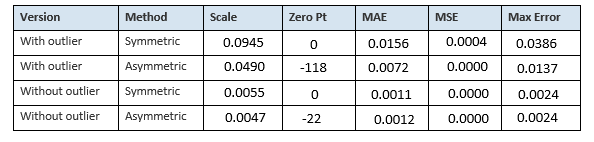

In [113]:
Image(filename="Documents/Outlier.png")